Maze 1: frozenset({np.int64(39), np.int64(7), np.int64(10), np.int64(42), np.int64(18), np.int64(20), np.int64(23), np.int64(26), np.int64(30)})
Maze 2: frozenset({37, 39, 7, 10, 42, 18, 20, 23, 30})

Port 1 → Port 2:
  Old paths: [[1, 4, 6, 8, 11, 14, 17, 13, 16, 12, 15, 19, 24, 29, 35, 40, 45, 41, 36, 31, 37, 32, 38, 49, 2]]
  New paths: [[1, 4, 6, 8, 11, 14, 17, 21, 26, 22, 27, 32, 38, 49, 2]]

Port 1 → Port 3:
  Old paths: [[1, 4, 6, 8, 11, 14, 17, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3]]
  New paths: [[1, 4, 6, 8, 11, 14, 17, 13, 16, 12, 15, 19, 24, 29, 34, 28, 33, 48, 3]]

Port 2 → Port 3:
  Old paths: [[2, 49, 38, 32, 37, 31, 36, 41, 45, 40, 35, 29, 34, 28, 33, 48, 3]]
  New paths: [[2, 49, 38, 32, 27, 22, 26, 31, 36, 41, 45, 40, 35, 29, 34, 28, 33, 48, 3]]
Port 1 → Port 2: divergence point = 17
Port 1 → Port 3: divergence point = None
Port 2 → Port 3: divergence point = 32


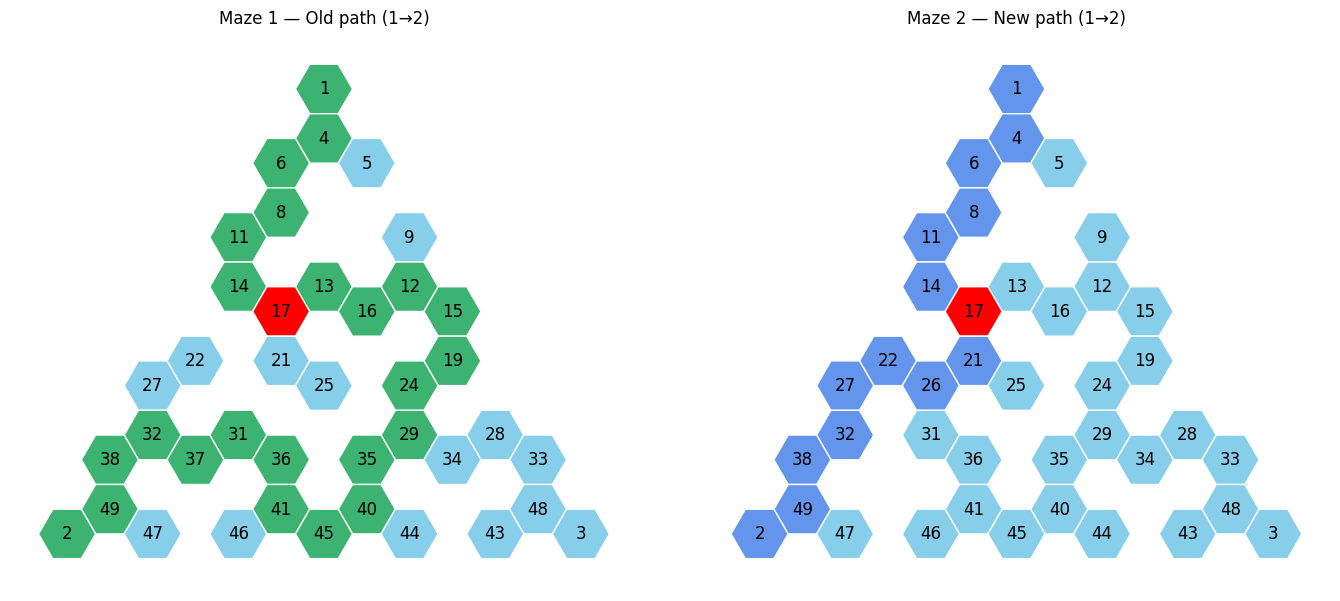


All hexes between hex 1 and hex 15: {1, 4, 5, 6, 8, 9, 11, 12, 13, 14, 15, 16, 17, 21, 25}


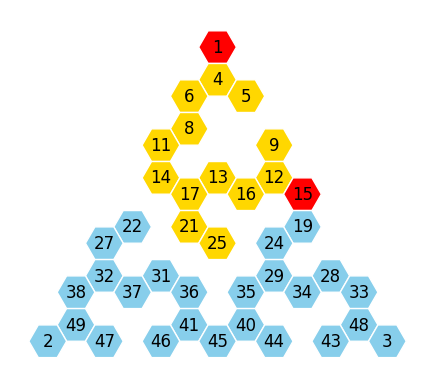

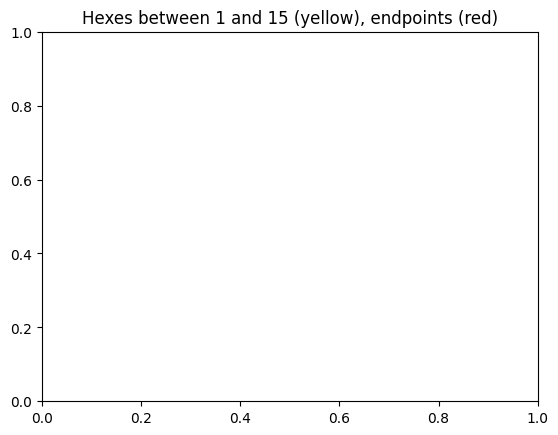

Port 1 → Port 2: hexes before divergence = {1, 4, 5, 6, 8, 11, 14, 17}, divergence at 17


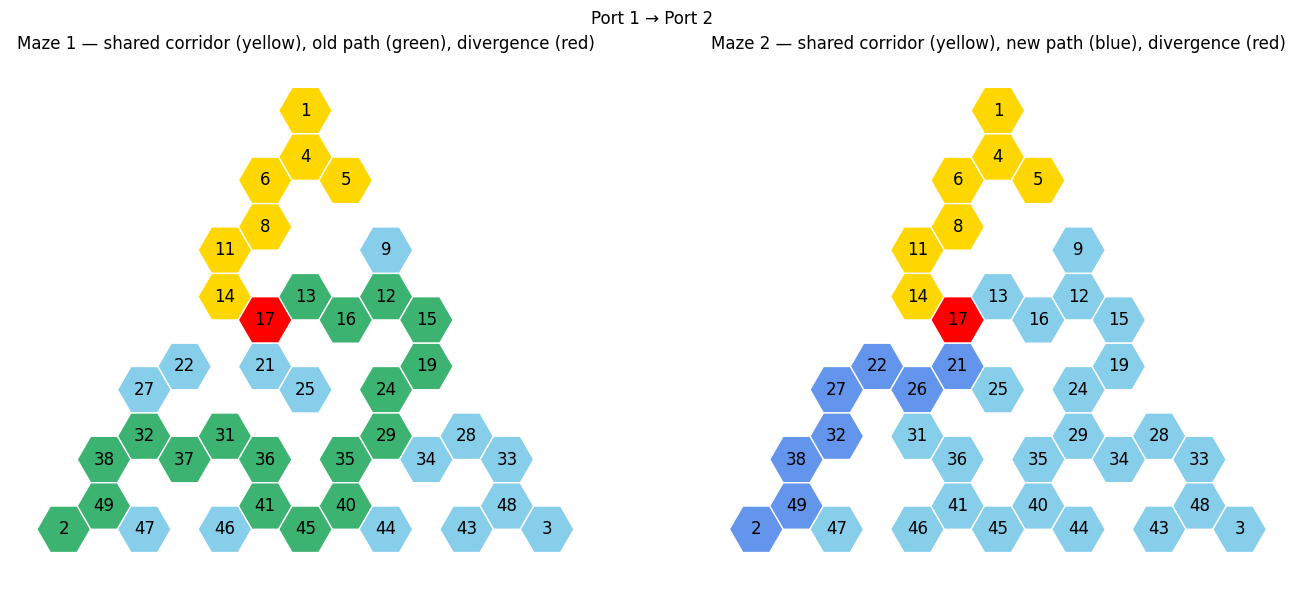

Port 1 → Port 3: paths are identical, no divergence
Port 2 → Port 3: hexes before divergence = {32, 49, 2, 38, 47}, divergence at 32


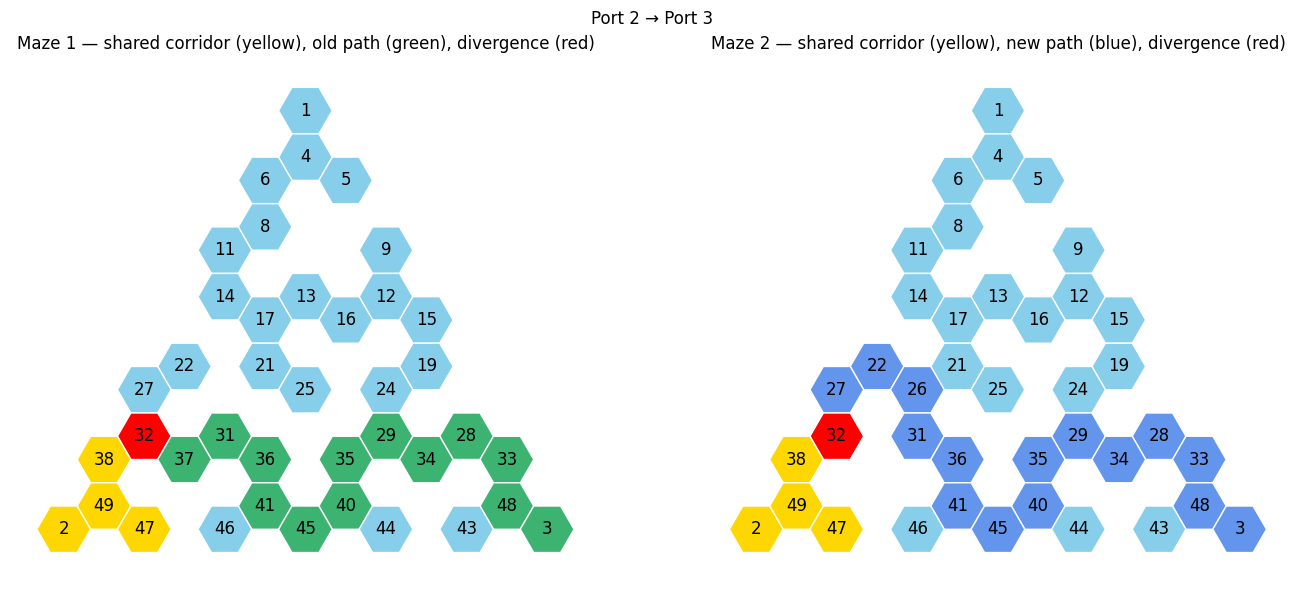

In [1]:
import pandas as pd
import sys
sys.path.append("..")

from src.hexmaze import (
    plot_hex_maze,
    get_optimal_paths,
    get_hexes_between,
    get_old_and_new_paths,
    get_path_divergence_point,
    get_hexes_before_divergence,
    get_barrier_change,
)

# Load the maze database and grab 2 mazes that differ by one barrier
maze_database = pd.read_pickle('../Maze_Databases/maze_configuration_database_new.pkl')
maze_1 = maze_database.iloc[0]['barriers']
maze_2 = maze_database.iloc[1]['barriers']

# Or if you have a barrier sequence handy:
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[0]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

print("Maze 1:", maze_1)
print("Maze 2:", maze_2)

# --- get_old_and_new_paths ---
# Compare old vs new optimal paths for each port pair
for start, end in [(1, 2), (1, 3), (2, 3)]:
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    print(f"\nPort {start} → Port {end}:")
    print(f"  Old paths: {old_paths}")
    print(f"  New paths: {new_paths}")

# --- get_path_divergence_point ---
# Find where the old and new paths diverge for each port pair
for start, end in [(1, 2), (1, 3), (2, 3)]:
    div_point = get_path_divergence_point(maze_1, maze_2, start, end)
    print(f"Port {start} → Port {end}: divergence point = {div_point}")

# --- Visualize old vs new paths side by side ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pick a port pair to visualize (change these to explore!)
start_port, end_port = 1, 2

old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start_port, end_port)
div_point = get_path_divergence_point(maze_1, maze_2, start_port, end_port)

# Highlight the divergence point and old path on maze 1
plot_hex_maze(
    maze_1,
    highlight_hexes=[set(old_paths[0]), {div_point} if div_point else set()],
    highlight_colors=["mediumseagreen", "red"],
    ax=axes[0],
    show_hex_labels=True,
    show_barriers=False,
)
axes[0].set_title(f"Maze 1 — Old path ({start_port}→{end_port})")

# Highlight the divergence point and new path on maze 2
plot_hex_maze(
    maze_2,
    highlight_hexes=[set(new_paths[0]), {div_point} if div_point else set()],
    highlight_colors=["cornflowerblue", "red"],
    ax=axes[1],
    show_hex_labels=True,
    show_barriers=False,
)
axes[1].set_title(f"Maze 2 — New path ({start_port}→{end_port})")

plt.tight_layout()
plt.show()

# --- get_hexes_between (core helper) ---
# Visualize all hexes between two hexes (including dead-end offshoots)
hex_a, hex_b = 1, 15  # Change these to explore!
hexes = get_hexes_between(maze_1, hex_a, hex_b)
print(f"\nAll hexes between hex {hex_a} and hex {hex_b}: {hexes}")

plot_hex_maze(
    maze_1,
    highlight_hexes=[hexes, {hex_a, hex_b}],
    highlight_colors=["gold", "red"],
    show_hex_labels=True,
    show_barriers=False,
)
plt.title(f"Hexes between {hex_a} and {hex_b} (yellow), endpoints (red)")
plt.show()

# --- get_hexes_before_divergence ---
# Visualize the corridor from start port to divergence point
for start, end in [(1, 2), (1, 3), (2, 3)]:
    before_div = get_hexes_before_divergence(maze_1, maze_2, start, end)
    div_point = get_path_divergence_point(maze_1, maze_2, start, end)

    if not before_div:
        print(f"Port {start} → Port {end}: paths are identical, no divergence")
        continue

    print(f"Port {start} → Port {end}: hexes before divergence = {before_div}, divergence at {div_point}")

    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Maze 1: show corridor before divergence + old path after divergence
    plot_hex_maze(
        maze_1,
        highlight_hexes=[before_div, set(old_paths[0]) - before_div, {div_point}],
        highlight_colors=["gold", "mediumseagreen", "red"],
        ax=axes[0],
        show_hex_labels=True,
        show_barriers=False,
    )
    axes[0].set_title(f"Maze 1 — shared corridor (yellow), old path (green), divergence (red)")

    # Maze 2: show corridor before divergence + new path after divergence
    plot_hex_maze(
        maze_2,
        highlight_hexes=[before_div, set(new_paths[0]) - before_div, {div_point}],
        highlight_colors=["gold", "cornflowerblue", "red"],
        ax=axes[1],
        show_hex_labels=True,
        show_barriers=False,
    )
    axes[1].set_title(f"Maze 2 — shared corridor (yellow), new path (blue), divergence (red)")

    plt.suptitle(f"Port {start} → Port {end}")
    plt.tight_layout()
    plt.show()


Barrier moved from hex 26 to hex 37


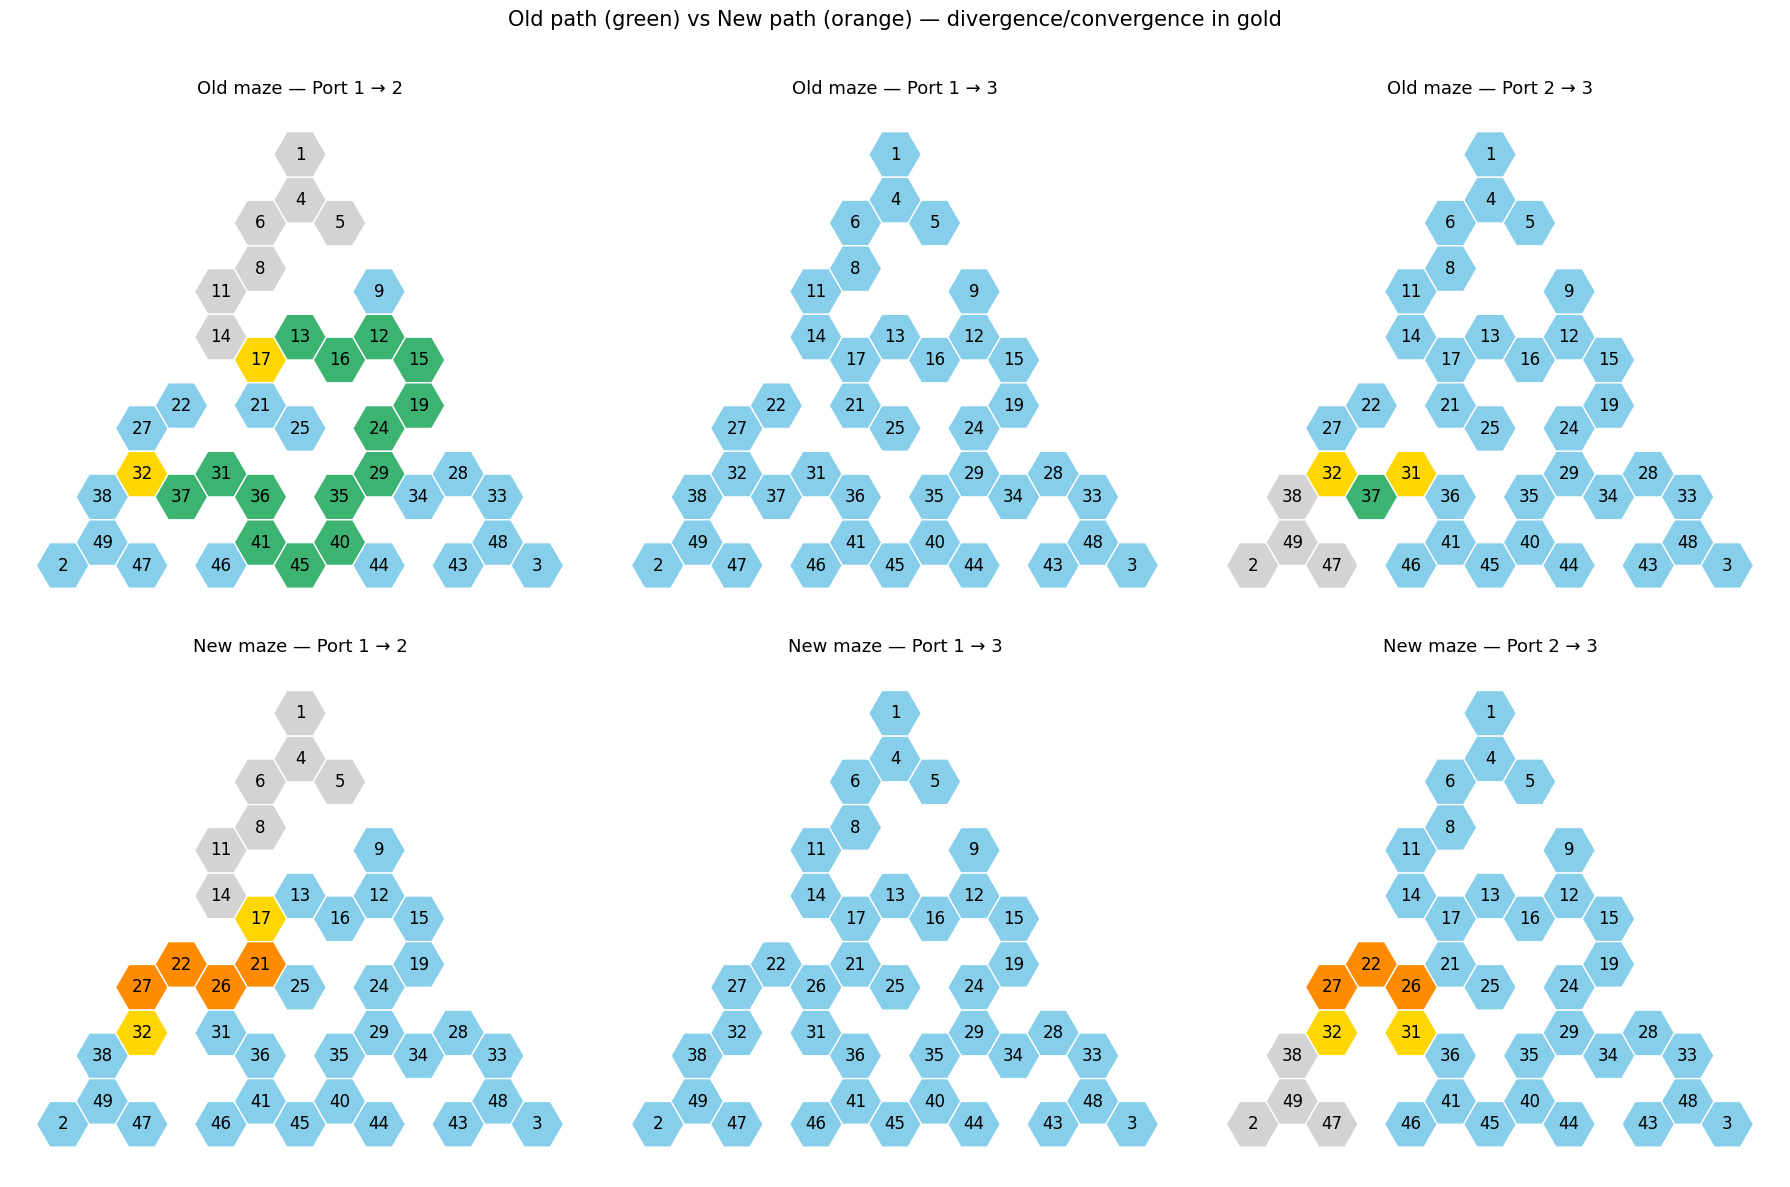

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

from src.hexmaze import (
    plot_hex_maze,
    get_old_and_new_paths,
    get_path_divergence_point,
    get_path_convergence_point,
    get_hexes_before_divergence,
    get_hexes_after_divergence,
    get_barrier_change,
)

# Load a barrier sequence so we have 2 mazes that differ by one barrier move
barrier_sequence_df = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_df.iloc[0]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

old_barrier, new_barrier = get_barrier_change(maze_1, maze_2)
print(f"Barrier moved from hex {old_barrier} to hex {new_barrier}")

# --- Plot 1: Old maze (top row) vs New maze (bottom row) for each port pair ---
port_pairs = [(1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, (start, end) in enumerate(port_pairs):
    divergence = get_path_divergence_point(maze_1, maze_2, start, end)
    convergence = get_path_convergence_point(maze_1, maze_2, start, end)
    before = get_hexes_before_divergence(maze_1, maze_2, start, end)
    old_after, new_after = get_hexes_after_divergence(maze_1, maze_2, start, end)

    # Divergence + convergence points for highlighting
    key_points = set()
    if divergence is not None:
        key_points.add(divergence)
    if convergence is not None:
        key_points.add(convergence)

    # Top row: old maze with old path highlighted
    highlight = [before - key_points, old_after, key_points] if key_points else [before]
    colors = ["lightgray", "mediumseagreen", "gold"] if key_points else ["lightgray"]
    plot_hex_maze(maze_1, highlight_hexes=highlight, highlight_colors=colors,
                  ax=axes[0, col], show_hex_labels=True, show_barriers=False)
    axes[0, col].set_title(f"Old maze — Port {start} → {end}", fontsize=13)

    # Bottom row: new maze with new path highlighted
    highlight = [before - key_points, new_after, key_points] if key_points else [before]
    colors = ["lightgray", "darkorange", "gold"] if key_points else ["lightgray"]
    plot_hex_maze(maze_2, highlight_hexes=highlight, highlight_colors=colors,
                  ax=axes[1, col], show_hex_labels=True, show_barriers=False)
    axes[1, col].set_title(f"New maze — Port {start} → {end}", fontsize=13)

plt.suptitle("Old path (green) vs New path (orange) — divergence/convergence in gold", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# # --- Plot 2: Same thing but without dead ends (dead_end_ok=False) ---
# fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# for col, (start, end) in enumerate(port_pairs):
#     divergence = get_path_divergence_point(maze_1, maze_2, start, end)
#     convergence = get_path_convergence_point(maze_1, maze_2, start, end)
#     before = get_hexes_before_divergence(maze_1, maze_2, start, end, dead_end_ok=False, non_optimal_ok=False)
#     old_after, new_after = get_hexes_after_divergence(maze_1, maze_2, start, end, dead_end_ok=False, non_optimal_ok=False)

#     key_points = set()
#     if divergence is not None:
#         key_points.add(divergence)
#     if convergence is not None:
#         key_points.add(convergence)

#     highlight = [before - key_points, old_after, key_points] if key_points else [before]
#     colors = ["lightgray", "mediumseagreen", "gold"] if key_points else ["lightgray"]
#     plot_hex_maze(maze_1, highlight_hexes=highlight, highlight_colors=colors,
#                   ax=axes[0, col], show_hex_labels=True, show_barriers=False)
#     axes[0, col].set_title(f"Old maze — Port {start} → {end}", fontsize=13)

#     highlight = [before - key_points, new_after, key_points] if key_points else [before]
#     colors = ["lightgray", "darkorange", "gold"] if key_points else ["lightgray"]
#     plot_hex_maze(maze_2, highlight_hexes=highlight, highlight_colors=colors,
#                   ax=axes[1, col], show_hex_labels=True, show_barriers=False)
#     axes[1, col].set_title(f"New maze — Port {start} → {end}", fontsize=13)

# plt.suptitle("Same as above but dead_end_ok=False", fontsize=15, y=1.01)
# plt.tight_layout()
# plt.show()
